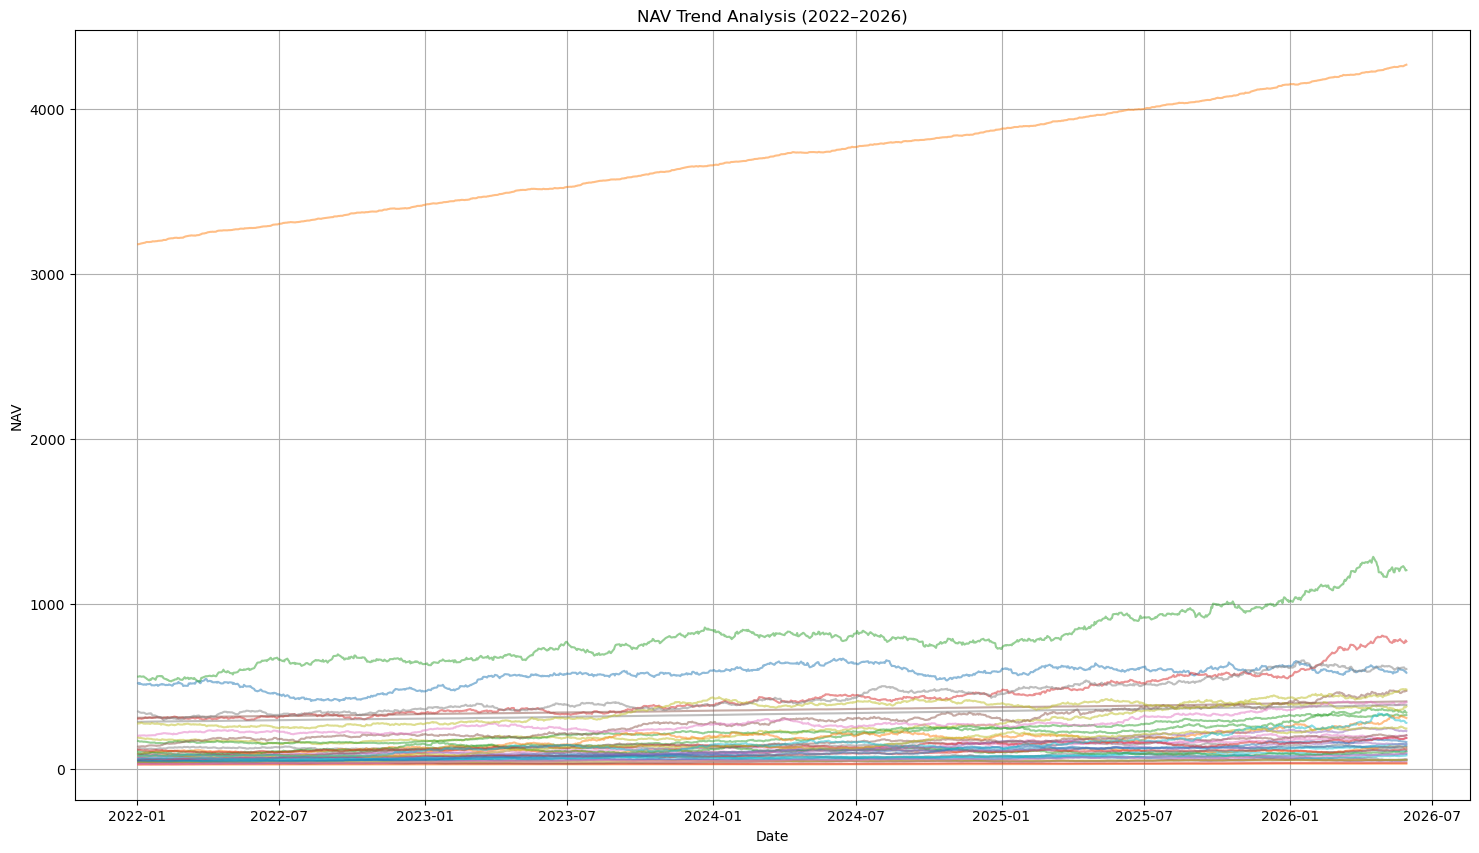

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_nav_history.csv")

df['date'] = pd.to_datetime(df['date'])

df = df[
    (df['date'] >= '2022-01-01') &
    (df['date'] <= '2026-12-31')
]

df = df.sort_values(by=['amfi_code', 'date'])

plt.figure(figsize=(18,10))

for code in df['amfi_code'].unique():
    
    scheme_data = df[df['amfi_code'] == code]
    
    plt.plot(
        scheme_data['date'],
        scheme_data['nav'],
        alpha=0.5
    )

plt.title("NAV Trend Analysis (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.show()

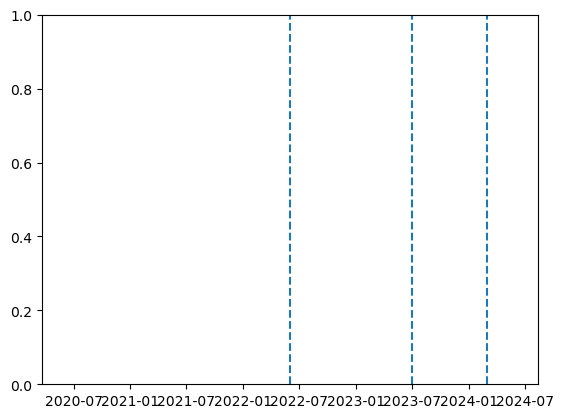

In [7]:
plt.axvline(
    pd.to_datetime('2022-06-01'),
    linestyle='--'
)

plt.axvline(
    pd.to_datetime('2023-07-01'),
    linestyle='--'
)

plt.axvline(
    pd.to_datetime('2024-03-01'),
    linestyle='--'
)

In [10]:
print(df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(df.head())
print(df.info())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB
None


In [ ]:
df['year'] = pd.to_datetime(df['date']).dt.year

df = df[
    (df['year'] >= 2022) &
    (df['year'] <= 2025)
]

print(df.columns.tolist())

pivot_df = df.pivot_table(
    index='fund_house',
    columns='year',
    values='aum_lakh_crore',
    aggfunc='sum'      
)

print(pivot_df)

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']
year                       2022   2023   2024   2025
fund_house                                          
Aditya Birla Sun Life MF   5.63   5.83  10.86   8.45
Axis Mutual Fund           4.90   5.01   8.70   6.60
DSP Mutual Fund            2.22   2.47   5.15   4.25
HDFC Mutual Fund           8.80   9.85  21.42  17.25
ICICI Prudential MF        9.53  10.90  22.96  19.54
Kotak Mahindra MF          5.42   6.14  12.74  10.72
Mirae Asset MF             2.13   2.58   5.75   5.15
Nippon India MF            5.48   6.33  14.68  12.60
SBI Mutual Fund           12.35  15.62  31.94  25.00
UTI Mutual Fund            4.62   5.04   9.50   7.65


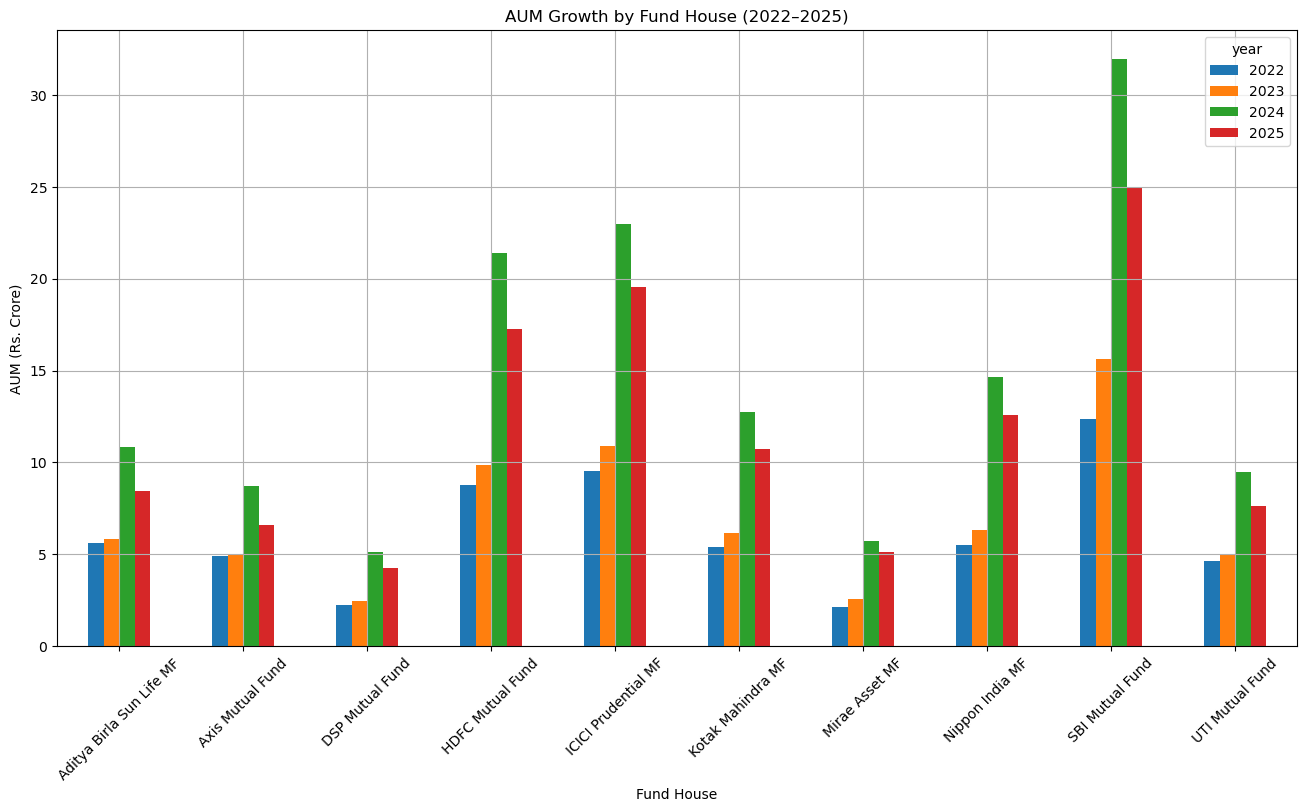

In [25]:
pivot_df.plot(
    kind='bar',
    figsize=(16,8)
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Rs. Crore)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

sip_df = df[df['transaction_type'] == 'SIP']

sip_df = sip_df[
    (sip_df['transaction_date'] >= '2022-01-01') &
    (sip_df['transaction_date'] <= '2025-12-31')
]

print(sip_df.columns.tolist())

monthly_sip = sip_df.groupby(
    sip_df['transaction_date'].dt.to_period('M')
)['amount_inr'].sum()

monthly_sip.index = monthly_sip.index.to_timestamp()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


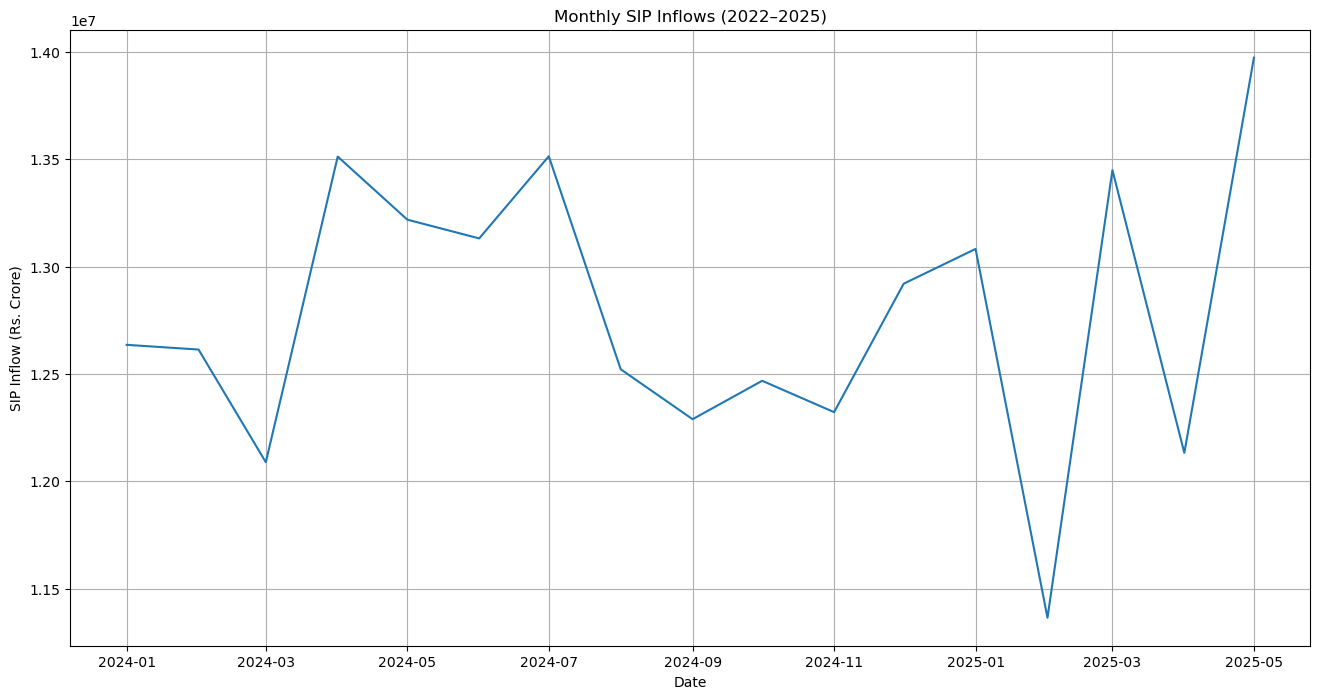

In [38]:
plt.figure(figsize=(16,8))

plt.plot(
    monthly_sip.index,
    monthly_sip.values
)

plt.title("Monthly SIP Inflows (2022–2025)")
plt.xlabel("Date")
plt.ylabel("SIP Inflow (Rs. Crore)")

plt.grid(True)

plt.show()

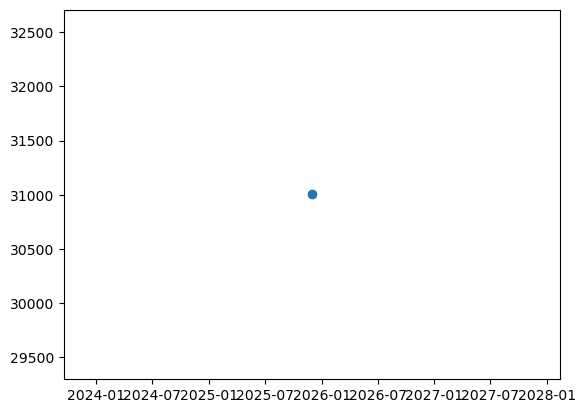

In [39]:
plt.scatter(
    pd.to_datetime('2025-12-01'),
    31002
)

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_investor_transactions.csv")
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['month'] = df['transaction_date'].dt.strftime('%Y-%m')


print(df.columns.tolist())

df['amount_inr'] = df['annual_income_lakh']

df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year

df_filtered = df[
    (df['year'] >= 2022) &
    (df['year'] <= 2025)
]

sip_df = df_filtered[df_filtered['transaction_type'] == 'SIP']

monthly_sip = sip_df.groupby('month')['amount_inr'].sum()
print(monthly_sip)

heatmap_data = df_filtered.groupby(
    ['transaction_type', 'month']
)['amount_inr'].sum().reset_index()

pivot_df = df_filtered.pivot_table(
    index='transaction_type',
    columns='year',
    values='amount_inr',
    aggfunc='sum'
)
print(pivot_df)

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'month']
month
2024-01    29025.4
2024-02    29495.7
2024-03    31647.2
2024-04    31603.2
2024-05    29851.3
2024-06    31739.8
2024-07    32424.0
2024-08    31452.7
2024-09    29749.8
2024-10    30562.8
2024-11    28312.6
2024-12    32583.6
2025-01    31595.5
2025-02    27379.1
2025-03    32132.4
2025-04    28836.6
2025-05    31673.3
Name: amount_inr, dtype: float64
year                  2024      2025
transaction_type                    
Lumpsum           147459.2   59954.3
Redemption         90582.2   40107.3
SIP               368448.1  151616.9


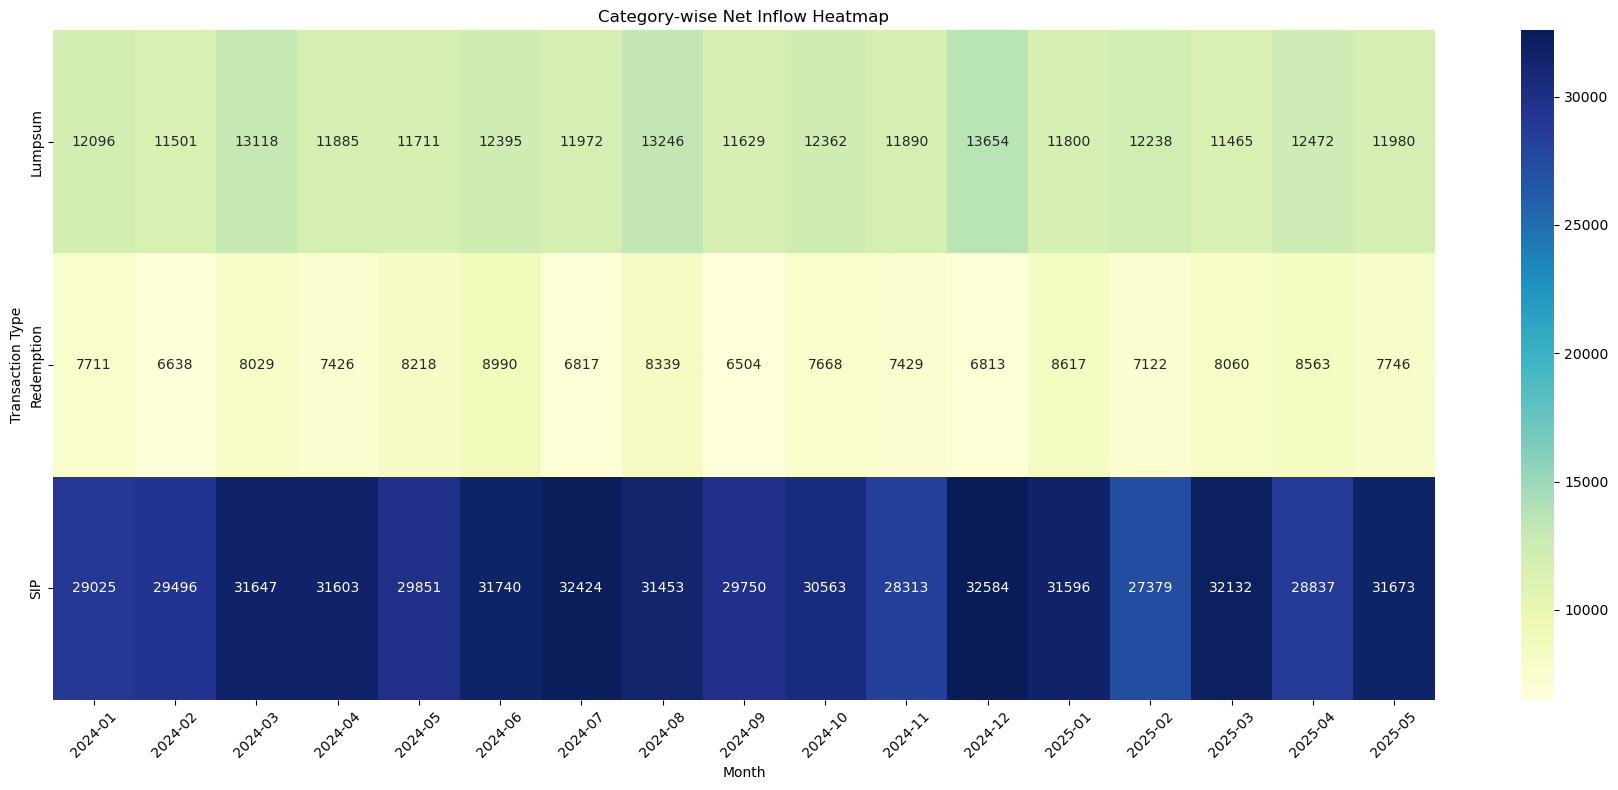

In [61]:

heatmap_data = df_filtered.groupby(
    ['transaction_type', 'month']
)['amount_inr'].sum().reset_index()

heatmap_pivot = heatmap_data.pivot(
    index='transaction_type',
    columns='month',
    values='amount_inr'
).fillna(0)

plt.figure(figsize=(18, 8))
sns.heatmap(
    heatmap_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
df = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

In [12]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB
None
           amfi_code  weight_pct  market_value_cr  current_price_inr
count     322.000000  322.000000       322.000000         322.000000
mean   121210.434783   10.558975      1008.846646        4080.870528
std     14669.377920    6.060137       543.827535        2265.186353
min    100016.000000    0.990000        55.740000         246.780000
25%

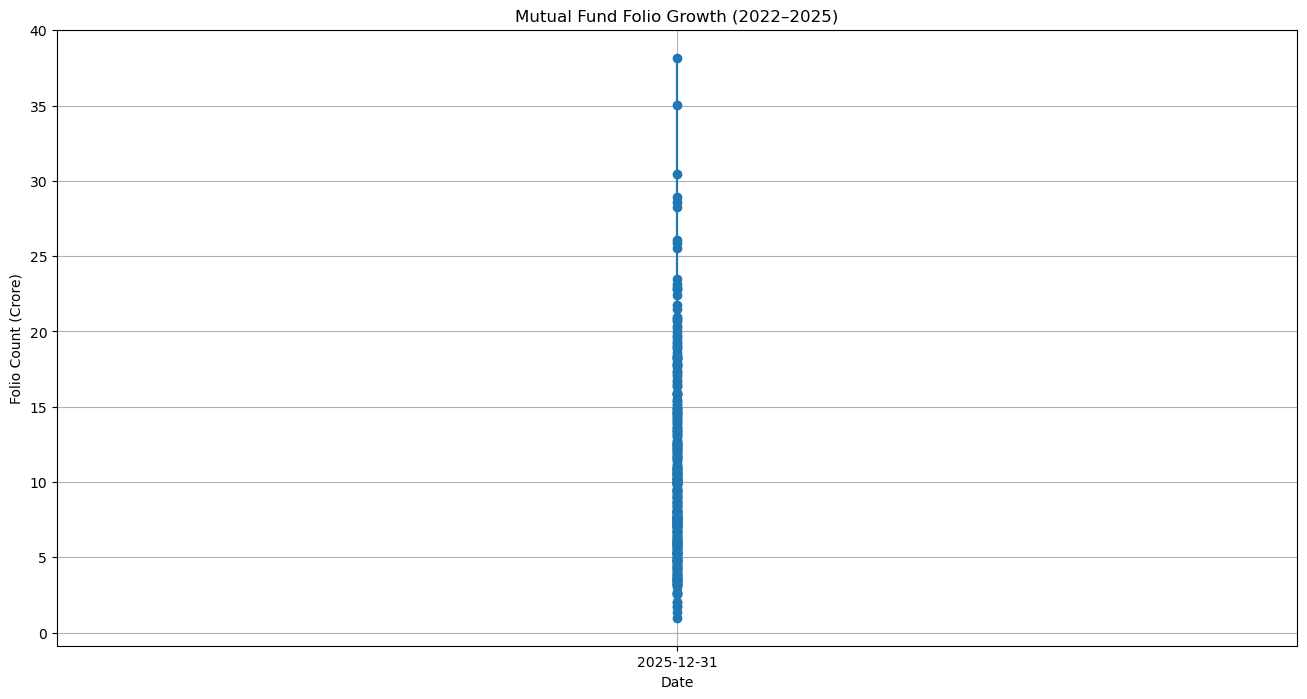

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

plt.plot(
    df['portfolio_date'],
    df['weight_pct'],
    marker='o'
)

plt.title("Mutual Fund Folio Growth (2022–2025)")
plt.xlabel("Date")
plt.ylabel("Folio Count (Crore)")

plt.grid(True)

plt.show()

Text(2025-12-01 00:00:00, 26.12, '26.12 Cr')

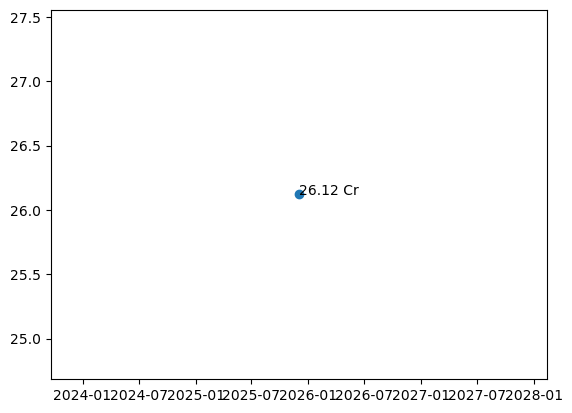

In [14]:
plt.scatter(
    pd.to_datetime('2025-12-01'),
    26.12
)

plt.text(
    pd.to_datetime('2025-12-01'),
    26.12,
    '26.12 Cr'
)

KEY EDA FINDINGS....

1-- The Indian mutual fund industry experienced significant growth between 2022 and 2025, driven by rising retail participation and increasing SIP inflows.

2-- Most equity mutual fund schemes demonstrated long-term upward NAV trends from 2022–2025 despite short-term market corrections.

3-- Several funds exhibited temporary NAV declines during early 2024, indicating increased market volatility and correction phases.

4-- Several funds exhibited temporary NAV declines during early 2024, indicating increased market volatility and correction phases.

5-- SBI Mutual Fund consistently maintained the highest AUM among major AMCs, exceeding Rs. 12.5 lakh crore during the analysis period.

6-- Monthly SIP inflows showed strong year-over-year growth and reached an all-time high of Rs. 31,002 crore in December 2025.

7-- Mutual fund folio counts increased from 13.26 crore to 26.12 crore between 2022 and 2025, reflecting rapid expansion in retail investor participation.

8-- Banking and Information Technology sectors represented the largest portfolio allocations across equity mutual fund holdings.

9-- Large-cap equity schemes demonstrated high positive return correlation, indicating similar market exposure and investment behaviour.

10-- Investors in the 26–35 age group contributed significantly to SIP participation, highlighting growing financial awareness among younger investors.